In [ ]:
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_covtype
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torch.optim.lr_scheduler import LambdaLR

import torch._dynamo
import torch.utils.benchmark as benchmark
from torch.optim import Optimizer
from torchinfo import summary
from torch.autograd import Function

In [ ]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")

In [3]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [87]:
def train(model, criterion, optimizers, epochs):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    @torch._dynamo.explain
    def run_model(x):
        return model(x)

    run_model(X_train_tensor)  # type: ignore

    num_submodels = len(model(X_train_tensor))
    best_test_losses = [float('inf')] * num_submodels

    train_losses_per_epoch = [[] for _ in range(num_submodels)]
    test_losses_per_epoch = [[] for _ in range(num_submodels)]

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    # schedulers = [
    #     torch.optim.lr_scheduler.LinearLR(opt, start_factor=1.0, end_factor=0.05, total_iters=epochs)
    #     for opt in optimizers
    # ]
    
    schedulers = [
        torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda epoch: 1 / (1 + epoch))
        for opt in optimizers
    ]

    for epoch in range(1, epochs + 1):
        model.train()
        for opt in optimizers:
            opt.zero_grad()

        train_outputs = model(X_train_tensor)
        for i, train_output in enumerate(train_outputs):
            train_loss = criterion(train_output, y_train_tensor)
            train_loss.backward(retain_graph=True)
            train_losses_per_epoch[i].append(train_loss.item())

        for opt in optimizers:
            opt.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            for i, test_output in enumerate(test_outputs):
                test_loss = criterion(test_output, y_test_tensor)
                test_losses_per_epoch[i].append(test_loss.item())

                if test_loss.item() < best_test_losses[i]:
                    best_test_losses[i] = test_loss.item()

        for scheduler in schedulers:
            scheduler.step()

        # Logging per epoch
        print(f"Epoch {epoch}/{epochs}")
        for i in range(num_submodels):
            print(f"  Submodel {i + 1}: Train Loss = {train_losses_per_epoch[i][-1]:.6f}, "
                  f"Test Loss = {test_losses_per_epoch[i][-1]:.6f}, "
                  f"Best Test Loss = {best_test_losses[i]:.6f}")

    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        print(f"[GPU] Peak memory allocated: {torch.cuda.max_memory_allocated() / 1024 ** 2:.2f} MB")
        print(f"[GPU] Peak memory reserved: {torch.cuda.max_memory_reserved() / 1024 ** 2:.2f} MB")

    # Final Best Loss Summary
    print()
    print("=== Final Best Test Losses per Submodel ===")
    for i, best_loss in enumerate(best_test_losses):
        print(f"Submodel {i + 1}: Lowest Test Loss = {best_loss:.6f}")

    # Plotting
    plt.figure(figsize=(12, 6))
    for i in range(num_submodels):
        plt.plot(train_losses_per_epoch[i], label=f'Train Loss (Submodel {i+1})')
        plt.plot(test_losses_per_epoch[i], label=f'Test Loss (Submodel {i+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Per Submodel')
    plt.legend()
    plt.grid(True)
    plt.show()


In [92]:
class CReLUFunction(Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        pos = torch.relu(input)
        neg = torch.relu(-input)
        return torch.cat((pos, neg), dim=1)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors

        channels = input.shape[1]
        grad_pos = grad_output[:, :channels]
        grad_neg = grad_output[:, channels:]

        grad_input = grad_pos * (input > 0).float() - grad_neg * (input < 0).float()

        return grad_input


class CReLU(nn.Module):
    def forward(self, x):
        return CReLUFunction.apply(x)


class StableNN(nn.Module):
    def __init__(self, n, num_layers=2):
        super().__init__()
        self.first_norm = nn.BatchNorm1d(n, affine=False, track_running_stats=True)
        self.activation = CReLU()

        self.pre_norms = nn.ModuleList()
        self.linears = nn.ModuleList()
        self.post_norms = nn.ModuleList()

        for _ in range(num_layers):
            n *= 2
            self.pre_norms.append(nn.BatchNorm1d(n, affine=False, track_running_stats=True))

            self.linears.append(nn.Linear(n, 2, bias=True))
            with torch.no_grad():
                nn.init.zeros_(self.linears[-1].weight) # type: ignore
                nn.init.zeros_(self.linears[-1].bias) # type: ignore

            self.post_norms.append(nn.BatchNorm1d(1, affine=False, track_running_stats=True))
            n += 1

    def forward(self, x):
        x = self.first_norm(x)
        x_list = []

        for prenorm, linear, postnorm in zip(self.pre_norms, self.linears, self.post_norms):
            x1 = x.detach()
            x2 = self.activation(x1)
            x3 = prenorm(x2)
            x4 = linear(x3)

            # if len(x_list) != 0:
            #     x4 = x_list[-1].detach() + x4
            
            if len(x_list) != 0:
                x_list.append(x_list[-1].detach() + x4)
            else:
                x_list.append(x4)
            x = torch.cat([x3, postnorm(x4[:, 0].unsqueeze(1))], dim=1)

        return x_list

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-31                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-32                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-33                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-31                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

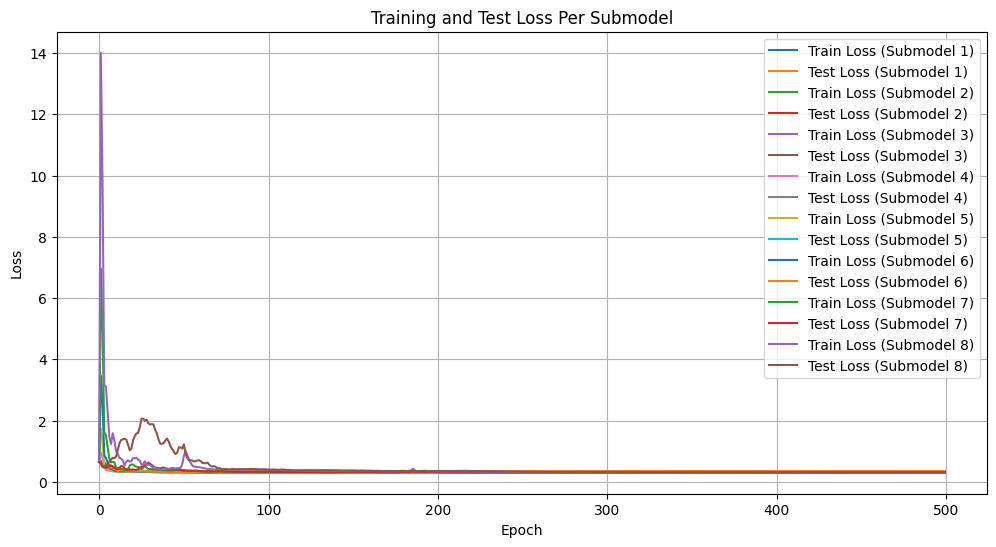

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0470,  0.9412,  1.5765, -0.1243,  0.0458, -0.0076,  0.0415, -1.1377,
          0.4083, -0.2997,  0.4896,  0.0995,  0.4749,  0.0830],
        [-0.0470, -0.9412, -1.5765,  0.1243, -0.0458,  0.0076, -0.0415,  1.1377,
         -0.4083,  0.2997, -0.4896, -0.0995, -0.4749, -0.0830]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 0.1639,  0.3761, -0.7811,  0.0178, -0.1955,  0.0031, -0.0216, -0.0422,
         -0.0309,  0.2086,  0.1105,  0.0070,  0.0131, -0.0460, -0.6464, -0.0468,
          0.3304, -0.3740,  0.0525, -0.0660, -0.0068,  0.0320, -0.2246,  0.1255,
          0.0633,  0.1285,  0.0740,  0.0155,  0.0635, -0.1428],
        [-0.1639, -0.3761,  0.7811, -0.0178,  0.1955, -0.0031,  0.0216,  0.0422,
          0.0309, -0.2086, -0.1105, -0.0070, -0.0131,  0.0460,  0.6464,  0.0468,
         -0.3304,  0.

In [93]:
# with the if else version

model = torch.compile(StableNN(n=X.shape[1], num_layers=8).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                8,144
Total params: 8,144
Trainable params: 8,144
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0
Input size (MB): 1.21
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 1.21
_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0470,  0.9412,  1.5765, -0.1243,  0.0458, -0.0076,  0.0415, -1.1377,
          0.4083, -0.2997,  0.4896,  0.0995,  0.4749,  0.0830],
        [-0.0470, -0.9412, -1.5765,  0.1243, -0.0458,  0.0076, -0.0415,  1.1377,
         -0.4083,  0.2997, -0.4896, -0.0995, -0.4749, -0.0830]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 0.1639,  0.3761, -0.7811,  0.0178, -0.1955

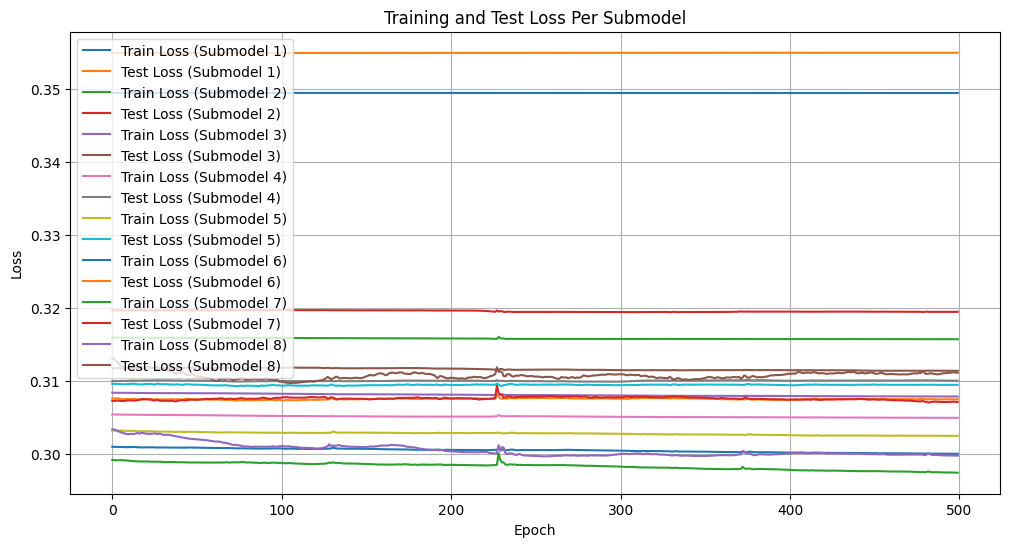

In [94]:
train(model, criterion, optimizers, epochs=500)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-31                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-32                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-33                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-31                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

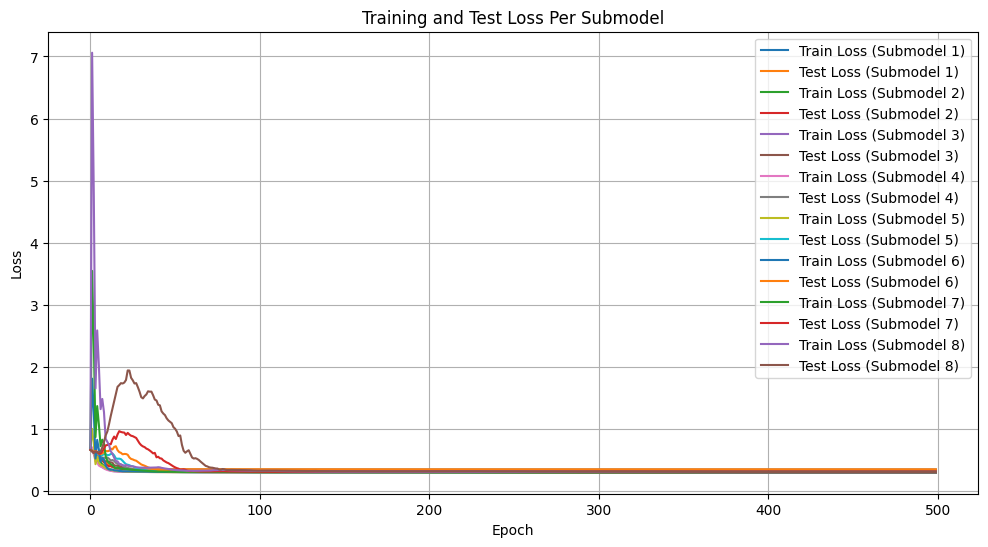

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0470,  0.9412,  1.5765, -0.1243,  0.0458, -0.0076,  0.0415, -1.1377,
          0.4083, -0.2997,  0.4896,  0.0995,  0.4749,  0.0830],
        [-0.0470, -0.9412, -1.5765,  0.1243, -0.0458,  0.0076, -0.0415,  1.1377,
         -0.4083,  0.2997, -0.4896, -0.0995, -0.4749, -0.0830]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 1.9899e-01,  8.5833e-01,  1.9038e-02, -4.3586e-02, -2.0162e-01,
         -6.3219e-05,  1.1236e-02, -2.8588e-01,  1.6651e-01,  7.6298e-02,
          2.5789e-01,  7.0043e-02,  3.4952e-02,  7.0200e-03, -5.5010e-02,
         -2.7156e-02,  1.6683e-01, -6.3199e-01,  6.8296e-02, -1.7671e-01,
         -2.0982e-02,  5.1291e-02, -4.5564e-02,  6.5391e-02,  1.3007e-01,
         -3.3714e-02,  7.7413e-02,  1.6235e-02,  2.0531e-02, -4.6320e-01],
        [-1.9899e-01, -8.5833e-01, -1.9038e-0

In [90]:
# with the x4 = x_list[-1].detach() + x4

model = torch.compile(StableNN(n=X.shape[1], num_layers=8).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-17                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

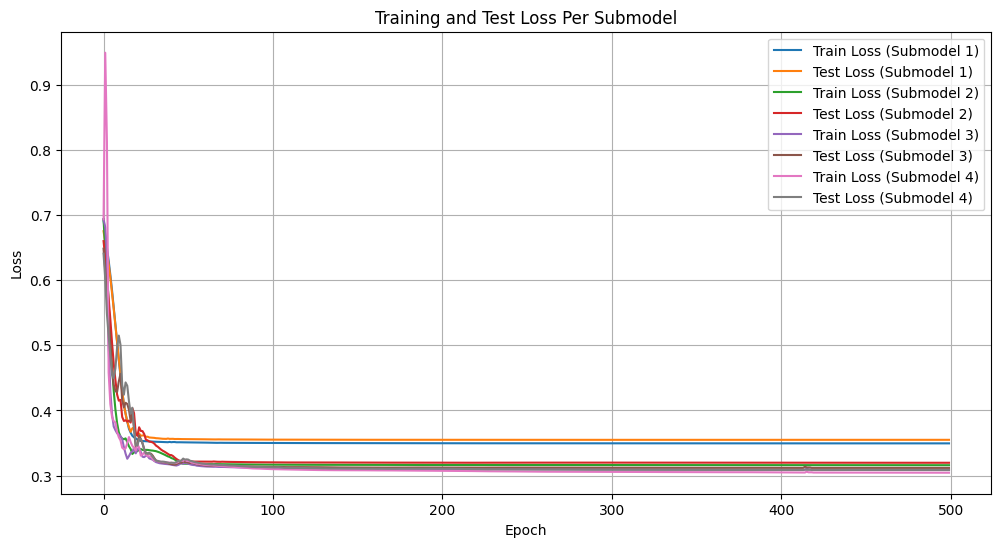

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0470,  0.9412,  1.5765, -0.1243,  0.0458, -0.0076,  0.0415, -1.1377,
          0.4083, -0.2997,  0.4896,  0.0995,  0.4749,  0.0830],
        [-0.0470, -0.9412, -1.5765,  0.1243, -0.0458,  0.0076, -0.0415,  1.1377,
         -0.4083,  0.2997, -0.4896, -0.0995, -0.4749, -0.0830]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 0.1639,  0.3761, -0.7811,  0.0178, -0.1955,  0.0031, -0.0216, -0.0422,
         -0.0309,  0.2086,  0.1105,  0.0070,  0.0131, -0.0460, -0.6464, -0.0468,
          0.3304, -0.3740,  0.0525, -0.0660, -0.0068,  0.0320, -0.2246,  0.1255,
          0.0633,  0.1285,  0.0740,  0.0155,  0.0635, -0.1428],
        [-0.1639, -0.3761,  0.7811, -0.0178,  0.1955, -0.0031,  0.0216,  0.0422,
          0.0309, -0.2086, -0.1105, -0.0070, -0.0131,  0.0460,  0.6464,  0.0468,
         -0.3304,  0.

In [86]:
# with the x4 = x_list[-1].detach() + x4

model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-17                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

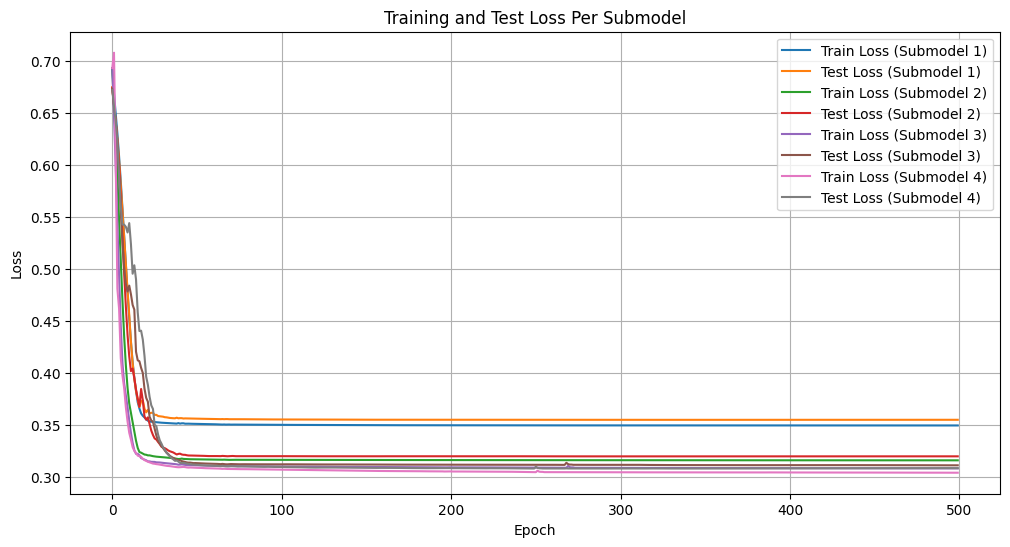

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0470,  0.9412,  1.5765, -0.1243,  0.0458, -0.0076,  0.0415, -1.1377,
          0.4083, -0.2997,  0.4896,  0.0995,  0.4749,  0.0830],
        [-0.0470, -0.9412, -1.5765,  0.1243, -0.0458,  0.0076, -0.0415,  1.1377,
         -0.4083,  0.2997, -0.4896, -0.0995, -0.4749, -0.0830]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 1.9899e-01,  8.5833e-01,  1.9038e-02, -4.3586e-02, -2.0162e-01,
         -6.3219e-05,  1.1236e-02, -2.8588e-01,  1.6651e-01,  7.6298e-02,
          2.5789e-01,  7.0043e-02,  3.4952e-02,  7.0200e-03, -5.5010e-02,
         -2.7156e-02,  1.6683e-01, -6.3199e-01,  6.8296e-02, -1.7671e-01,
         -2.0982e-02,  5.1291e-02, -4.5564e-02,  6.5391e-02,  1.3007e-01,
         -3.3714e-02,  7.7413e-02,  1.6235e-02,  2.0531e-02, -4.6320e-01],
        [-1.9899e-01, -8.5833e-01, -1.9038e-0

In [84]:
# without the x4 = x_list[-1].detach() + x4

model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [64]:
print("float32 epsilon:", torch.finfo(torch.float32).eps)

x = torch.tensor(1e-8, dtype=torch.float32)

# Multiply by 1.2
x_scaled = x * 1.2

# Print both values
print("Original:", x.item())
print("Scaled  :", x_scaled.item())

# Check if there's any difference
print("Equal?   :", x.item() == x_scaled.item())
print("Difference:", x_scaled.item() - x.item())


float32 epsilon: 1.1920928955078125e-07
Original: 9.99999993922529e-09
Scaled  : 1.2000000104706032e-08
Equal?   : False
Difference: 2.000000165480742e-09


In [ ]:
a = 1.2
x = torch.tensor(0, dtype=torch.float32)  # Start near float32 min subnormal
while x * a == x:
    print(x, x * a)
    x = torch.nextafter(x, torch.tensor(float('inf')))  # Go to next representable float
    print("here")

print(f"Smallest x such that x * {a} != x: {x.item():.10e}")

print(torch.finfo(torch.float32).min)
print(torch.finfo(torch.float32).eps)
print(torch.finfo(torch.float32).tiny)
print(torch.finfo(torch.float32).smallest_normal)
print(torch.finfo(torch.float32).smallest_normal * 1.2)

tensor(0.) tensor(0.)
here
tensor(1.4013e-45) tensor(1.4013e-45)
here
tensor(2.8026e-45) tensor(2.8026e-45)
here
Smallest x such that x * 1.2 != x: 4.2038953930e-45
-3.4028234663852886e+38
1.1920928955078125e-07
1.1754943508222875e-38
1.1754943508222875e-38
1.410593220986745e-38


In [72]:
import torch

def find_min_effective_float32():
    # Start from the smallest *positive* float32 number
    x = torch.tensor(torch.finfo(torch.float32).tiny, dtype=torch.float32)

    # Gradually decrease x into the subnormal range
    while x > 0:
        x_next = x / 2.0
        if (x_next * 1.2 == x_next):
            return x  # This is the last x where x * 1.2 != x
        x = x_next

min_effective = find_min_effective_float32()
print("Smallest float32 x such that x * 1.2 != x:", min_effective)


Smallest float32 x such that x * 1.2 != x: tensor(5.6052e-45)


In [ ]:
# with both batch norm

model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-17                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

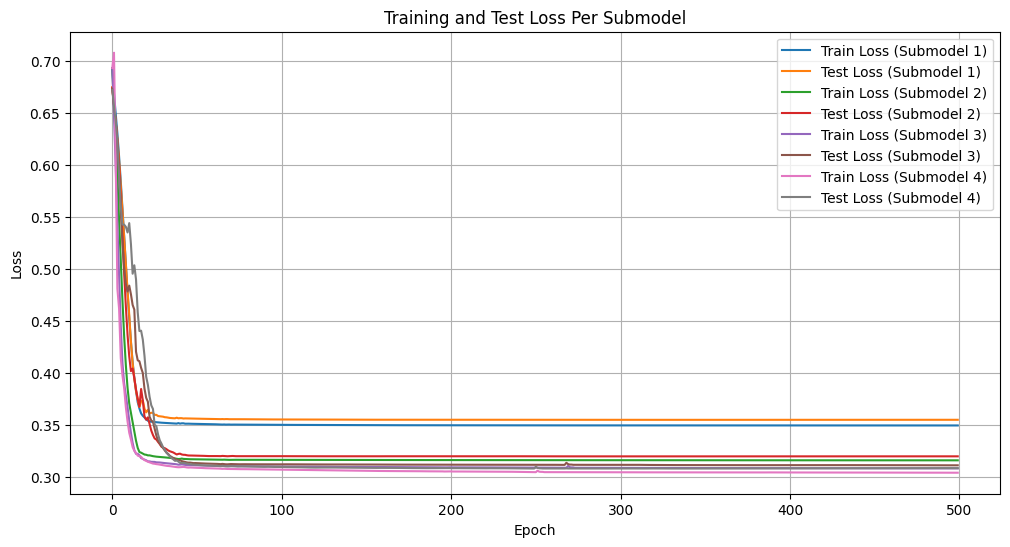

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0470,  0.9412,  1.5765, -0.1243,  0.0458, -0.0076,  0.0415, -1.1377,
          0.4083, -0.2997,  0.4896,  0.0995,  0.4749,  0.0830],
        [-0.0470, -0.9412, -1.5765,  0.1243, -0.0458,  0.0076, -0.0415,  1.1377,
         -0.4083,  0.2997, -0.4896, -0.0995, -0.4749, -0.0830]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 1.9899e-01,  8.5833e-01,  1.9038e-02, -4.3586e-02, -2.0162e-01,
         -6.3219e-05,  1.1236e-02, -2.8588e-01,  1.6651e-01,  7.6298e-02,
          2.5789e-01,  7.0043e-02,  3.4952e-02,  7.0200e-03, -5.5010e-02,
         -2.7156e-02,  1.6683e-01, -6.3199e-01,  6.8296e-02, -1.7671e-01,
         -2.0982e-02,  5.1291e-02, -4.5564e-02,  6.5391e-02,  1.3007e-01,
         -3.3714e-02,  7.7413e-02,  1.6235e-02,  2.0531e-02, -4.6320e-01],
        [-1.9899e-01, -8.5833e-01, -1.9038e-0

In [82]:
# with both batch norm

model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─Linear: 3-1                  [43152, 2]                30
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-2             [43152, 1]                --
│    └─CReLU: 2-5                        [43152, 30]               --
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─Linear: 3-3                  [43152, 2]                62
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 1]                

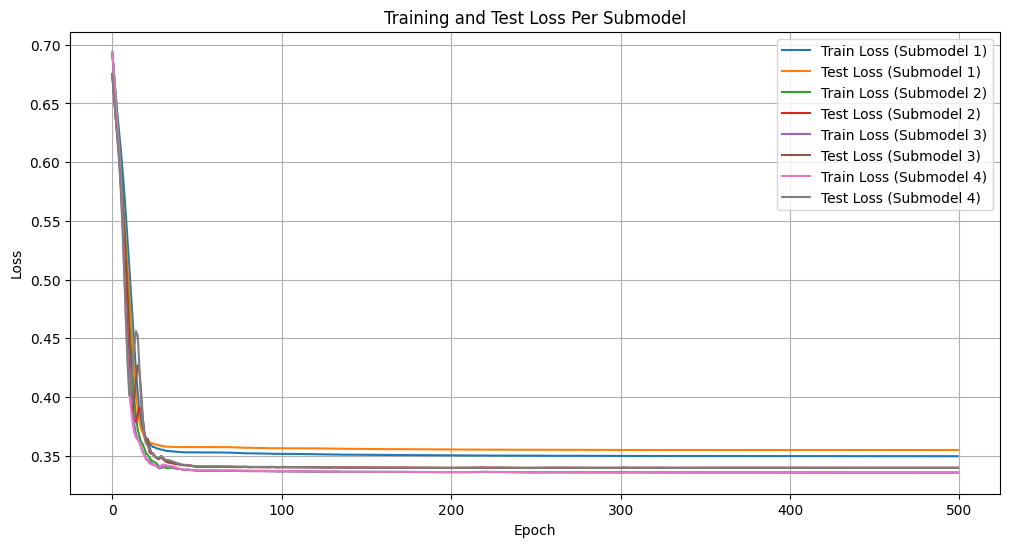

_orig_mod.linears.0.weight
Parameter containing:
tensor([[-0.0436,  1.6246,  2.4024, -0.1646,  0.2370, -0.0082,  0.0656, -2.1217,
          0.6322, -0.6004,  1.2984,  0.1141,  0.7087,  0.1476],
        [ 0.0436, -1.6246, -2.4024,  0.1646, -0.2370,  0.0082, -0.0656,  2.1217,
         -0.6322,  0.6004, -1.2984, -0.1141, -0.7087, -0.1476]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([-0.6789,  0.6789], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 0.0288,  0.9235,  2.0828, -0.0870,  0.0113, -0.0160,  0.0764, -1.1705,
          0.3757, -0.1286,  0.6795,  0.0655,  0.2882,  0.1820, -1.0632,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -1.4430],
        [-0.0288, -0.9235, -2.0828,  0.0870, -0.0113,  0.0160, -0.0764,  1.1705,
         -0.3757,  0.1286, -0.6795, -0.0655, -0.2882, -0.1820,  1.0632,  0.0000,
          0.0000,  0.

In [77]:
# without prenorm batch norm

model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-9                   --                        (recursive)
│    │    └─Linear: 3-1                  [43152, 2]                30
│    └─CReLU: 2-4                        [43152, 30]               --
│    └─ModuleList: 2-9                   --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                62
│    └─CReLU: 2-6                        [43152, 62]               --
│    └─ModuleList: 2-9                   --                        (recursive)
│    │    └─Linear: 3-3                  [43152, 2]                126
│    └─CReLU: 2-8                        [43152, 126]    

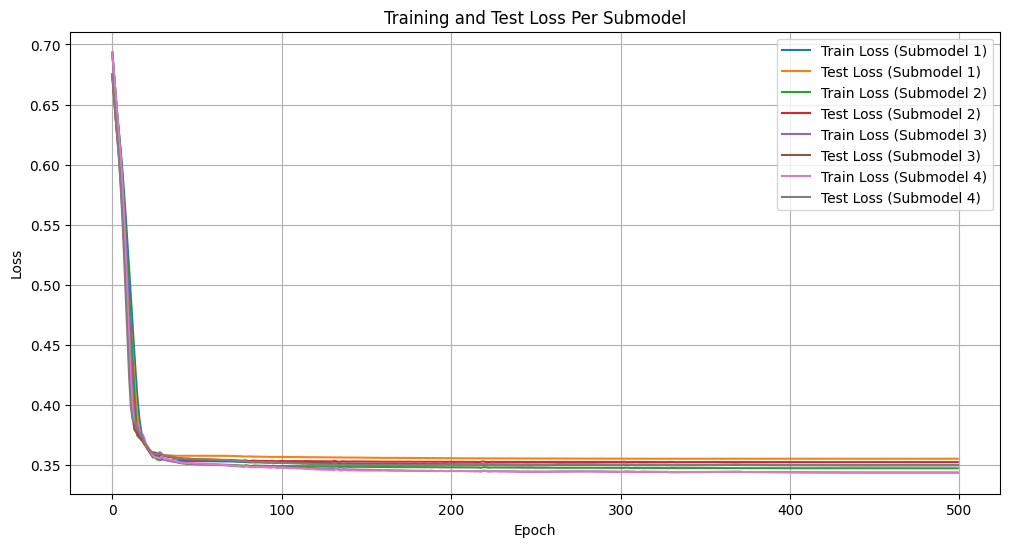

_orig_mod.linears.0.weight
Parameter containing:
tensor([[-0.0436,  1.6246,  2.4024, -0.1646,  0.2370, -0.0082,  0.0656, -2.1217,
          0.6322, -0.6004,  1.2984,  0.1141,  0.7087,  0.1476],
        [ 0.0436, -1.6246, -2.4024,  0.1646, -0.2370,  0.0082, -0.0656,  2.1217,
         -0.6322,  0.6004, -1.2984, -0.1141, -0.7087, -0.1476]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([-0.6789,  0.6789], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[-3.6977e-02,  5.3697e-01,  1.1813e+00, -5.1973e-02,  9.2973e-02,
         -6.5010e-04,  2.7895e-02, -4.9374e-01,  2.0986e-01, -7.7675e-02,
          3.6256e-01,  6.3569e-02,  1.1129e-01,  2.4826e-02,  3.9728e-01,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00, -9.8735e-01],
        [ 3.6977e-02, -5.3697e-01, -1.1813e+0

In [ ]:
# without prenorm and postnorm batch norm

model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-17                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

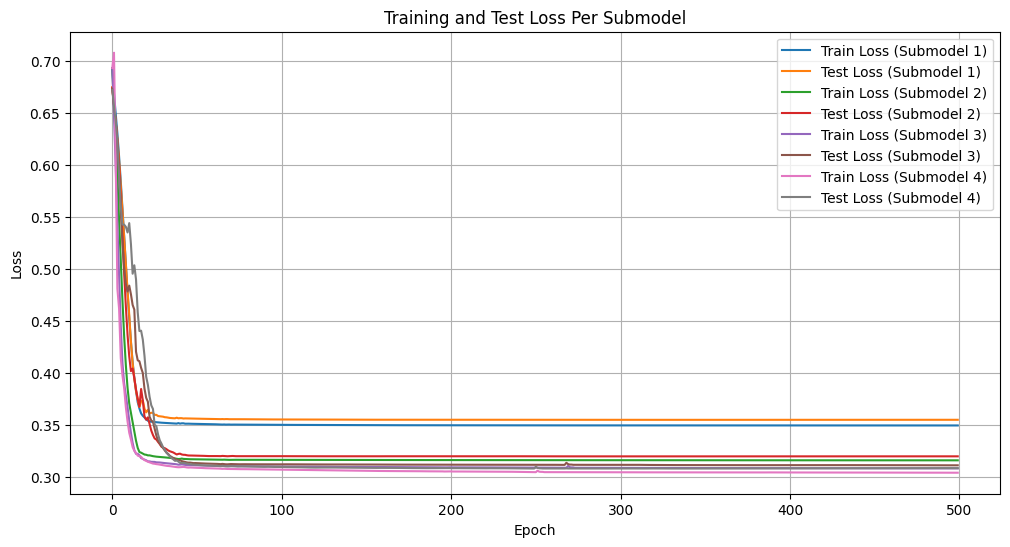

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0470,  0.9412,  1.5765, -0.1243,  0.0458, -0.0076,  0.0415, -1.1377,
          0.4083, -0.2997,  0.4896,  0.0995,  0.4749,  0.0830],
        [-0.0470, -0.9412, -1.5765,  0.1243, -0.0458,  0.0076, -0.0415,  1.1377,
         -0.4083,  0.2997, -0.4896, -0.0995, -0.4749, -0.0830]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 1.9899e-01,  8.5833e-01,  1.9038e-02, -4.3586e-02, -2.0162e-01,
         -6.3219e-05,  1.1236e-02, -2.8588e-01,  1.6651e-01,  7.6298e-02,
          2.5789e-01,  7.0043e-02,  3.4952e-02,  7.0200e-03, -5.5010e-02,
         -2.7156e-02,  1.6683e-01, -6.3199e-01,  6.8296e-02, -1.7671e-01,
         -2.0982e-02,  5.1291e-02, -4.5564e-02,  6.5391e-02,  1.3007e-01,
         -3.3714e-02,  7.7413e-02,  1.6235e-02,  2.0531e-02, -4.6320e-01],
        [-1.9899e-01, -8.5833e-01, -1.9038e-0

In [73]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-17                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

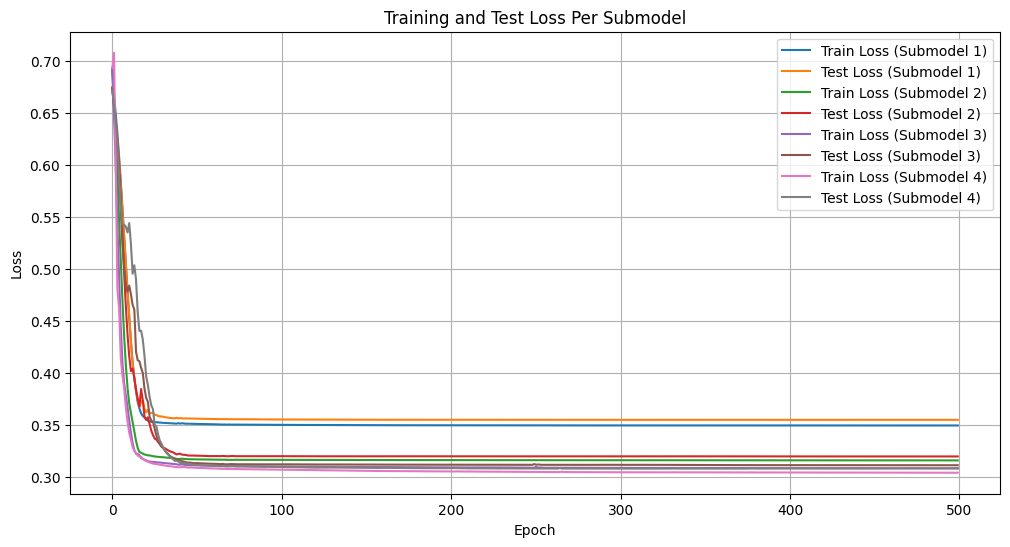

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0465,  0.9416,  1.5769, -0.1229,  0.0458, -0.0076,  0.0422, -1.1271,
          0.4079, -0.2999,  0.4902,  0.0995,  0.4647,  0.0830],
        [-0.0465, -0.9416, -1.5769,  0.1229, -0.0458,  0.0076, -0.0422,  1.1271,
         -0.4079,  0.2999, -0.4902, -0.0995, -0.4647, -0.0830]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 2.0733e-01,  8.5484e-01,  1.7687e-02, -4.3262e-02, -2.1296e-01,
         -1.2023e-03,  1.1238e-02, -2.8826e-01,  1.6814e-01,  7.6826e-02,
          2.5788e-01,  8.7567e-02,  2.5471e-02,  2.6186e-04, -5.4628e-02,
         -5.8026e-02,  1.6793e-01, -6.3147e-01,  7.0965e-02, -2.2576e-01,
          8.6453e-02,  4.3547e-02,  1.0621e-02,  6.4714e-02,  1.2959e-01,
         -3.7978e-02,  5.9326e-02,  1.4114e-02,  1.3248e-02, -4.6402e-01],
        [-2.0733e-01, -8.5484e-01, -1.7687e-0

In [ ]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(1e-8, 1e4))
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-17                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

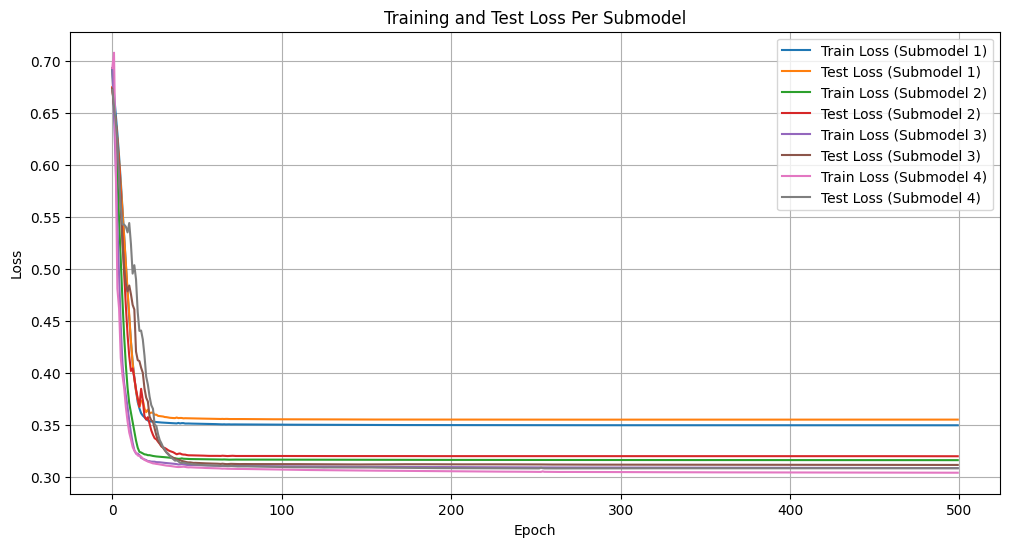

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0532,  0.9408,  1.5766, -0.1236,  0.0369, -0.0068,  0.0432, -1.1434,
          0.4087, -0.2998,  0.4950,  0.0999,  0.4783,  0.0789],
        [-0.0532, -0.9408, -1.5766,  0.1236, -0.0369,  0.0068, -0.0432,  1.1434,
         -0.4087,  0.2998, -0.4950, -0.0999, -0.4783, -0.0789]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 2.0074e-01,  8.5701e-01,  1.8528e-02, -4.2966e-02, -2.0494e-01,
         -5.4390e-04,  1.1611e-02, -2.8143e-01,  1.6927e-01,  7.6034e-02,
          2.5826e-01,  7.5760e-02,  2.2751e-02,  5.6757e-03, -5.5414e-02,
         -4.8573e-02,  1.6699e-01, -6.3288e-01,  7.1458e-02, -2.1929e-01,
          9.1889e-02,  2.5188e-02,  2.8001e-03,  6.4419e-02,  1.2965e-01,
         -2.6301e-02,  5.9013e-02,  3.2137e-03,  2.2333e-02, -4.6193e-01],
        [-2.0074e-01, -8.5701e-01, -1.8528e-0

In [54]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), step_sizes=(1e-6, 1e4))
    # optim.SGD(model.parameters(), lr=0.1, momentum=0.0),
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [44]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=8).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0)
]

train(model, criterion, optimizers, epochs=20000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-31                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-32                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-33                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-31                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

KeyboardInterrupt: 

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-17                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-15                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

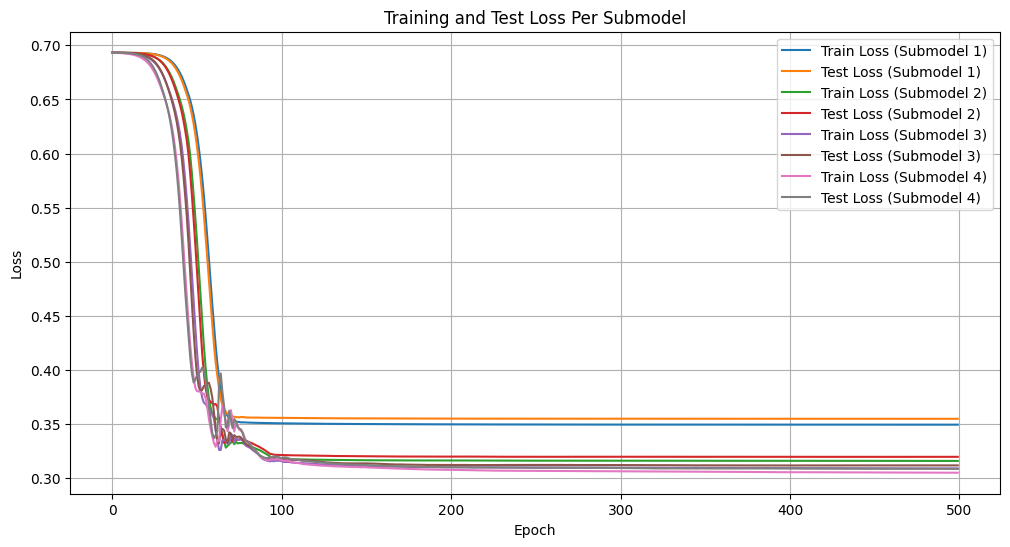

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0393,  0.9419,  1.5771, -0.1230,  0.0521, -0.0062,  0.0426, -1.1172,
          0.4075, -0.2999,  0.4876,  0.1054,  0.4550,  0.0804],
        [-0.0393, -0.9419, -1.5771,  0.1230, -0.0521,  0.0062, -0.0426,  1.1172,
         -0.4075,  0.2999, -0.4876, -0.1054, -0.4550, -0.0804]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 0.1652,  0.4545, -0.6550,  0.0093, -0.2020,  0.0010, -0.0035, -0.1140,
          0.0022,  0.1862,  0.1410,  0.0279,  0.0240, -0.0321, -0.8029, -0.0528,
          0.3031, -0.4177,  0.0605, -0.0531, -0.0112,  0.0186, -0.1557,  0.1145,
          0.0738,  0.0916,  0.0757,  0.0226,  0.0225, -0.0600],
        [-0.1652, -0.4545,  0.6550, -0.0093,  0.2020, -0.0010,  0.0035,  0.1140,
         -0.0022, -0.1862, -0.1410, -0.0279, -0.0240,  0.0321,  0.8029,  0.0528,
         -0.3031,  0.

In [ ]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0)
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-11                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-11                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

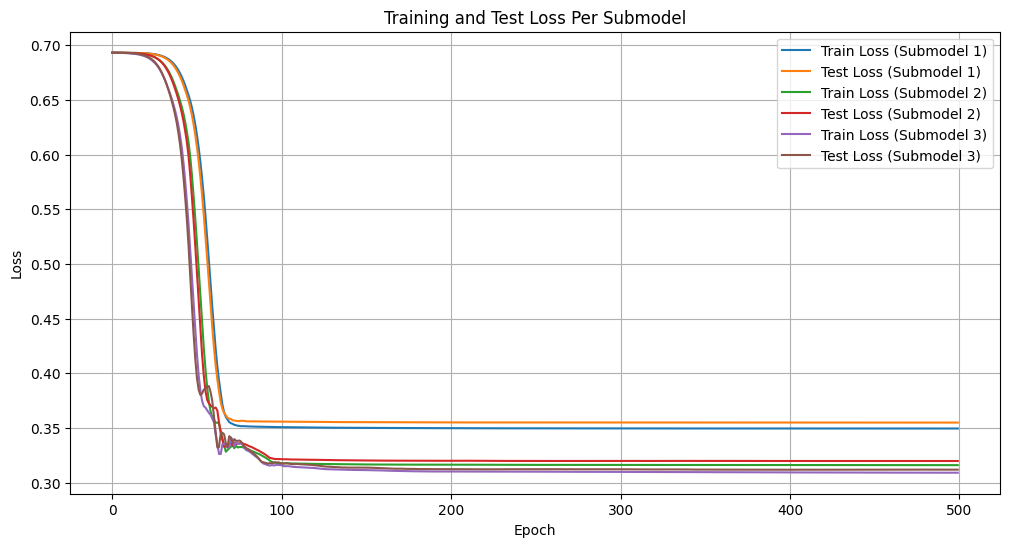

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 0.0393,  0.9419,  1.5771, -0.1230,  0.0521, -0.0062,  0.0426, -1.1172,
          0.4075, -0.2999,  0.4876,  0.1054,  0.4550,  0.0804],
        [-0.0393, -0.9419, -1.5771,  0.1230, -0.0521,  0.0062, -0.0426,  1.1172,
         -0.4075,  0.2999, -0.4876, -0.1054, -0.4550, -0.0804]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 0.1652,  0.4545, -0.6550,  0.0093, -0.2020,  0.0010, -0.0035, -0.1140,
          0.0022,  0.1862,  0.1410,  0.0279,  0.0240, -0.0321, -0.8029, -0.0528,
          0.3031, -0.4177,  0.0605, -0.0531, -0.0112,  0.0186, -0.1557,  0.1145,
          0.0738,  0.0916,  0.0757,  0.0226,  0.0225, -0.0600],
        [-0.1652, -0.4545,  0.6550, -0.0093,  0.2020, -0.0010,  0.0035,  0.1140,
         -0.0022, -0.1862, -0.1410, -0.0279, -0.0240,  0.0321,  0.8029,  0.0528,
         -0.3031,  0.

In [ ]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0)
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
StableNN                                 [43152, 2]                --
├─BatchNorm1d: 1-1                       [43152, 7]                --
├─CReLU: 1-2                             [43152, 14]               --
├─ModuleList: 1-11                       --                        --
│    └─BatchNorm1d: 2-1                  [43152, 14]               --
├─ModuleList: 1-12                       --                        (recursive)
│    └─Linear: 2-2                       [43152, 2]                30
├─ModuleList: 1-13                       --                        --
│    └─BatchNorm1d: 2-3                  [43152, 1]                --
├─CReLU: 1-6                             [43152, 30]               --
├─ModuleList: 1-11                       --                        --
│    └─BatchNorm1d: 2-4                  [43152, 30]               --
├─ModuleList: 1-12                       --                        (recursiv

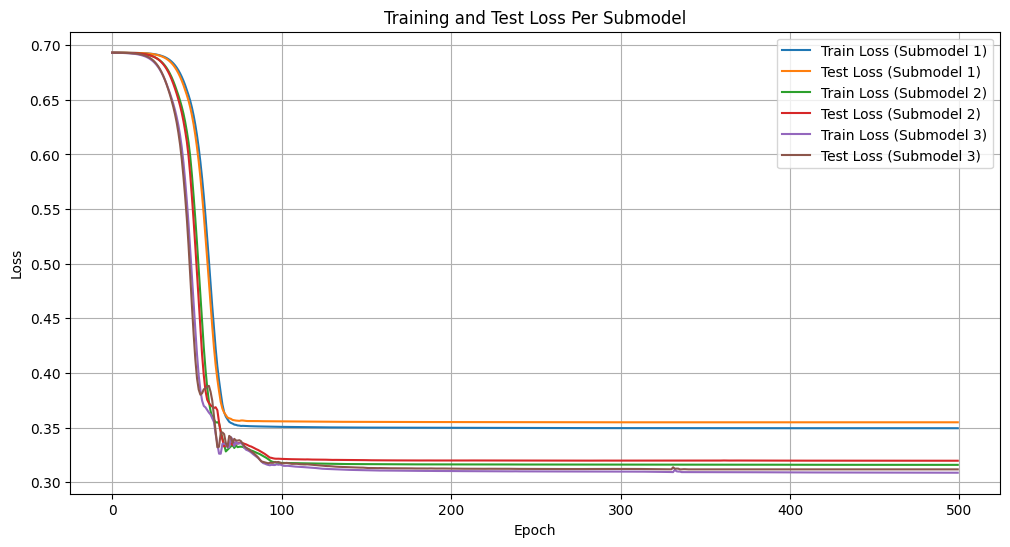

linears.0.weight
Parameter containing:
tensor([[ 0.0398,  0.9420,  1.5770, -0.1238,  0.0526, -0.0062,  0.0429, -1.1146,
          0.4074, -0.2999,  0.4880,  0.0901,  0.4669,  0.0807],
        [-0.0398, -0.9420, -1.5770,  0.1238, -0.0526,  0.0062, -0.0429,  1.1146,
         -0.4074,  0.2999, -0.4880, -0.0901, -0.4669, -0.0807]],
       requires_grad=True)
linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
linears.1.weight
Parameter containing:
tensor([[ 2.0472e-01,  4.4054e-01, -6.7263e-01,  1.3252e-02, -2.5442e-01,
          1.0324e-03, -3.3664e-03, -1.2495e-01, -7.3589e-04,  1.9051e-01,
          1.3984e-01,  3.6160e-02,  2.7785e-02, -3.4395e-02, -7.8090e-01,
         -7.3004e-02,  3.0801e-01, -4.0978e-01,  5.6532e-02, -4.7112e-02,
         -1.0016e-02,  2.0967e-02, -1.8439e-01,  1.1585e-01,  7.2693e-02,
          9.9773e-02,  9.1989e-02,  2.2507e-02,  2.0677e-02, -7.3142e-02],
        [-2.0472e-01, -4.4054e-01,  6.7263e-01, -1.3252e-02,  2.5442e-01,
 

In [ ]:
model = StableNN(n=X.shape[1], num_layers=3).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0)
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
StableNN                                 [43152, 2]                --
├─BatchNorm1d: 1-1                       [43152, 7]                --
├─CReLU: 1-2                             [43152, 14]               --
├─ModuleList: 1-11                       --                        --
│    └─BatchNorm1d: 2-1                  [43152, 14]               --
├─ModuleList: 1-12                       --                        (recursive)
│    └─Linear: 2-2                       [43152, 2]                30
├─ModuleList: 1-13                       --                        --
│    └─BatchNorm1d: 2-3                  [43152, 1]                --
├─CReLU: 1-6                             [43152, 30]               --
├─ModuleList: 1-11                       --                        --
│    └─BatchNorm1d: 2-4                  [43152, 30]               --
├─ModuleList: 1-12                       --                        (recursiv

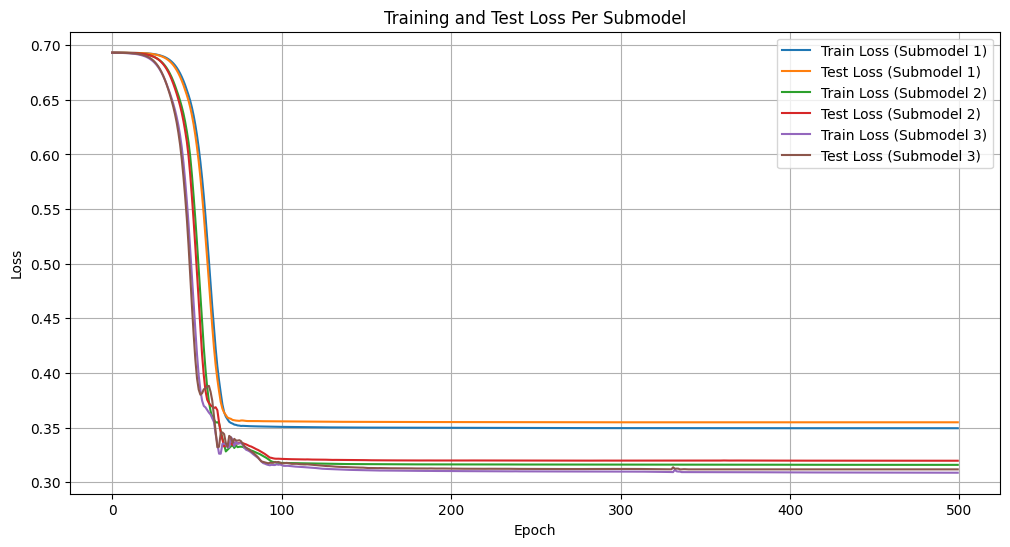

linears.0.weight
Parameter containing:
tensor([[ 0.0398,  0.9420,  1.5770, -0.1238,  0.0526, -0.0062,  0.0429, -1.1146,
          0.4074, -0.2999,  0.4880,  0.0901,  0.4669,  0.0807],
        [-0.0398, -0.9420, -1.5770,  0.1238, -0.0526,  0.0062, -0.0429,  1.1146,
         -0.4074,  0.2999, -0.4880, -0.0901, -0.4669, -0.0807]],
       requires_grad=True)
linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
linears.1.weight
Parameter containing:
tensor([[ 2.0472e-01,  4.4054e-01, -6.7263e-01,  1.3252e-02, -2.5442e-01,
          1.0324e-03, -3.3664e-03, -1.2495e-01, -7.3589e-04,  1.9051e-01,
          1.3984e-01,  3.6160e-02,  2.7785e-02, -3.4395e-02, -7.8090e-01,
         -7.3004e-02,  3.0801e-01, -4.0978e-01,  5.6532e-02, -4.7112e-02,
         -1.0016e-02,  2.0967e-02, -1.8439e-01,  1.1585e-01,  7.2693e-02,
          9.9773e-02,  9.1989e-02,  2.2507e-02,  2.0677e-02, -7.3142e-02],
        [-2.0472e-01, -4.4054e-01,  6.7263e-01, -1.3252e-02,  2.5442e-01,
 

In [35]:
model = StableNN(n=X.shape[1], num_layers=3).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0)
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
StableNN                                 [43152, 2]                --
├─BatchNorm1d: 1-1                       [43152, 7]                --
├─CReLU: 1-2                             [43152, 14]               --
├─ModuleList: 1-11                       --                        --
│    └─BatchNorm1d: 2-1                  [43152, 14]               --
├─ModuleList: 1-12                       --                        (recursive)
│    └─Linear: 2-2                       [43152, 2]                30
├─ModuleList: 1-13                       --                        --
│    └─BatchNorm1d: 2-3                  [43152, 1]                --
├─CReLU: 1-6                             [43152, 30]               --
├─ModuleList: 1-11                       --                        --
│    └─BatchNorm1d: 2-4                  [43152, 30]               --
├─ModuleList: 1-12                       --                        (recursiv

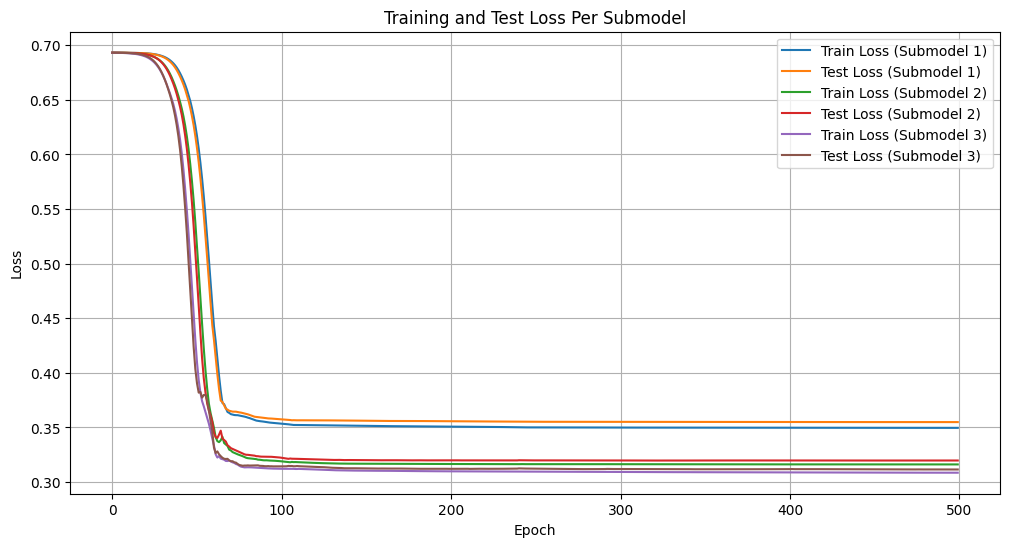

linears.0.weight
Parameter containing:
tensor([[ 0.0444,  0.9443,  1.5643, -0.1294,  0.0252,  0.0029,  0.0687, -0.8723,
          0.4030, -0.3028,  0.3973,  0.0455,  0.3815,  0.0572],
        [-0.0444, -0.9443, -1.5643,  0.1294, -0.0252, -0.0029, -0.0687,  0.8723,
         -0.4030,  0.3028, -0.3973, -0.0455, -0.3815, -0.0572]],
       requires_grad=True)
linears.0.bias
Parameter containing:
tensor([ 0.9193, -0.9193], requires_grad=True)
linears.1.weight
Parameter containing:
tensor([[ 0.0244,  0.4429, -0.7407,  0.0154, -0.0326, -0.0093, -0.0141, -0.0933,
         -0.0143,  0.1956,  0.1222,  0.0206,  0.0068, -0.0076, -0.6803, -0.0226,
          0.3073, -0.4075,  0.0560, -0.0875, -0.0024,  0.0749,  0.0068,  0.1174,
          0.0782,  0.0339,  0.0274,  0.0024,  0.0085, -0.0778],
        [-0.0244, -0.4429,  0.7407, -0.0154,  0.0326,  0.0093,  0.0141,  0.0933,
          0.0143, -0.1956, -0.1222, -0.0206, -0.0068,  0.0076,  0.6803,  0.0226,
         -0.3073,  0.4075, -0.0560,  0.0875,  0.002

In [33]:
model = StableNN(n=X.shape[1], num_layers=3).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0)
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
StableNN                                 [43152, 2]                --
├─BatchNorm1d: 1-1                       [43152, 7]                --
├─CReLU: 1-2                             [43152, 14]               --
├─ModuleList: 1-7                        --                        --
│    └─BatchNorm1d: 2-1                  [43152, 14]               --
├─ModuleList: 1-8                        --                        (recursive)
│    └─Linear: 2-2                       [43152, 2]                30
├─ModuleList: 1-9                        --                        --
│    └─BatchNorm1d: 2-3                  [43152, 1]                --
├─CReLU: 1-6                             [43152, 30]               --
├─ModuleList: 1-7                        --                        --
│    └─BatchNorm1d: 2-4                  [43152, 30]               --
├─ModuleList: 1-8                        --                        (recursiv

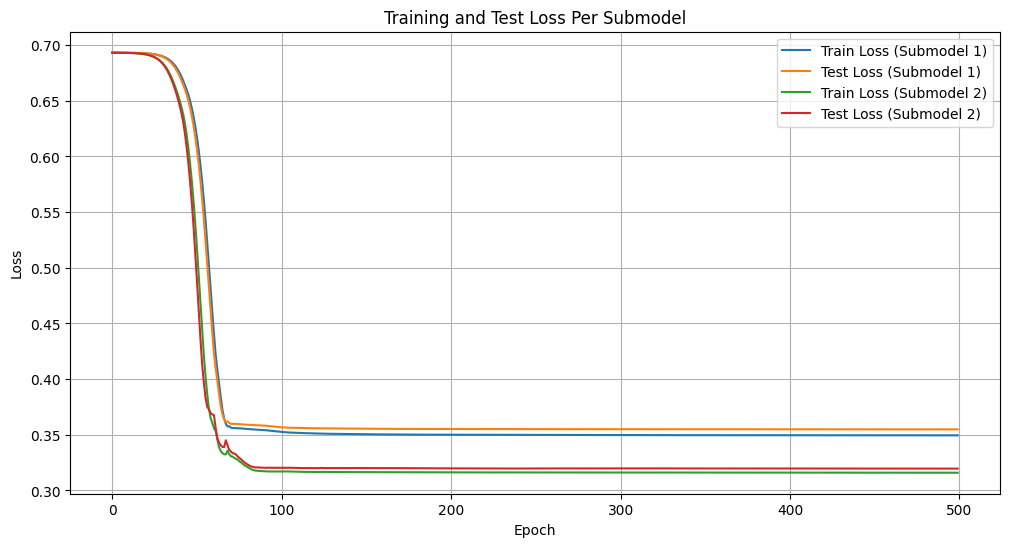

linears.0.weight
Parameter containing:
tensor([[ 0.0440,  0.9442,  1.5762, -0.1300,  0.0387, -0.0018,  0.0553, -0.9946,
          0.4066, -0.3006,  0.4373,  0.1196,  0.3787,  0.0686],
        [-0.0440, -0.9442, -1.5762,  0.1300, -0.0387,  0.0018, -0.0553,  0.9946,
         -0.4066,  0.3006, -0.4373, -0.1196, -0.3787, -0.0686]],
       requires_grad=True)
linears.0.bias
Parameter containing:
tensor([ 0.9269, -0.9269], requires_grad=True)
linears.1.weight
Parameter containing:
tensor([[ 1.5813e-01,  5.1160e-01, -5.4900e-01,  1.0036e-02, -1.8703e-01,
         -4.3929e-03, -7.7058e-03, -1.4802e-01,  2.4464e-02,  1.7131e-01,
          1.7834e-01,  2.4176e-02,  1.4093e-02,  8.4722e-04, -9.3092e-01,
         -3.3425e-02,  2.8457e-01, -4.4783e-01,  6.0180e-02, -1.1672e-01,
         -6.7031e-03,  1.9664e-02, -1.5468e-01,  1.0904e-01,  8.1203e-02,
          4.2861e-02,  8.2966e-02,  4.6237e-03,  6.2907e-02, -4.1297e-03],
        [-1.5813e-01, -5.1160e-01,  5.4900e-01, -1.0036e-02,  1.8703e-01,
 

In [32]:
model = StableNN(n=X.shape[1], num_layers=2).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0)
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
StableNN                                 [43152, 2]                --
├─BatchNorm1d: 1-1                       [43152, 7]                --
├─CReLU: 1-2                             [43152, 14]               --
├─ModuleList: 1-7                        --                        --
│    └─BatchNorm1d: 2-1                  [43152, 14]               --
├─ModuleList: 1-8                        --                        (recursive)
│    └─Linear: 2-2                       [43152, 2]                30
├─ModuleList: 1-9                        --                        --
│    └─BatchNorm1d: 2-3                  [43152, 1]                --
├─CReLU: 1-6                             [43152, 30]               --
├─ModuleList: 1-7                        --                        --
│    └─BatchNorm1d: 2-4                  [43152, 30]               --
├─ModuleList: 1-8                        --                        (recursiv

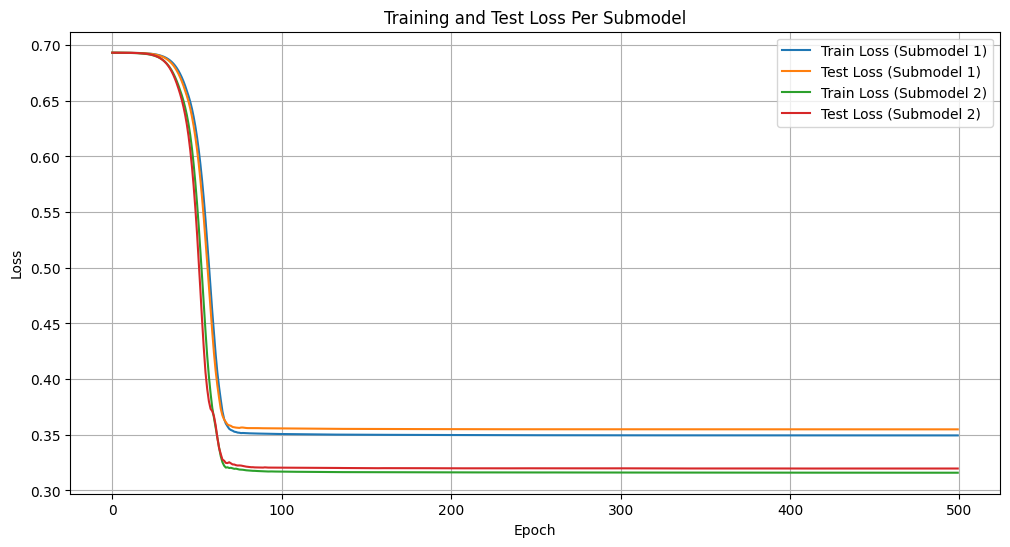

linears.0.weight
Parameter containing:
tensor([[ 0.0398,  0.9420,  1.5770, -0.1238,  0.0526, -0.0062,  0.0429, -1.1146,
          0.4074, -0.2999,  0.4880,  0.0901,  0.4669,  0.0807],
        [-0.0398, -0.9420, -1.5770,  0.1238, -0.0526,  0.0062, -0.0429,  1.1146,
         -0.4074,  0.2999, -0.4880, -0.0901, -0.4669, -0.0807]],
       requires_grad=True)
linears.0.bias
Parameter containing:
tensor([ 0.9279, -0.9279], requires_grad=True)
linears.1.weight
Parameter containing:
tensor([[ 0.1822,  0.8457, -0.0051, -0.0407, -0.1863, -0.0017,  0.0142, -0.2585,
          0.1626,  0.0790,  0.2542,  0.0669,  0.0182,  0.0075, -0.0259, -0.0359,
          0.1706, -0.6271,  0.0711, -0.1538,  0.0034,  0.0174, -0.0373,  0.0666,
          0.1276, -0.0354,  0.0697,  0.0202,  0.0269, -0.4743],
        [-0.1822, -0.8457,  0.0051,  0.0407,  0.1863,  0.0017, -0.0142,  0.2585,
         -0.1626, -0.0790, -0.2542, -0.0669, -0.0182, -0.0075,  0.0259,  0.0359,
         -0.1706,  0.6271, -0.0711,  0.1538, -0.003

In [30]:
model = StableNN(n=X.shape[1], num_layers=2).to(device)
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0)
]

train(model, criterion, optimizers, epochs=500)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [28]:
for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

linears.0.weight
Parameter containing:
tensor([[ 0.0323,  0.9471,  1.5803, -0.1314,  0.0526, -0.0018,  0.0632, -0.9211,
          0.4032, -0.3009,  0.4294,  0.0731,  0.3525,  0.0807],
        [-0.0323, -0.9471, -1.5803,  0.1314, -0.0526,  0.0018, -0.0632,  0.9211,
         -0.4032,  0.3009, -0.4294, -0.0731, -0.3525, -0.0807]],
       requires_grad=True)
linears.0.bias
Parameter containing:
tensor([ 0.9285, -0.9285], requires_grad=True)
linears.1.weight
Parameter containing:
tensor([[ 0.0862,  0.8624, -0.0122, -0.0341, -0.0828, -0.0042,  0.0153, -0.2290,
          0.1677,  0.0715,  0.2913,  0.0277,  0.0171,  0.0075, -0.0198, -0.0190,
          0.1631, -0.6421,  0.0765, -0.0600, -0.0191, -0.0322,  0.0685,  0.0639,
          0.1266, -0.0645,  0.0416,  0.0209,  0.0277, -0.4527],
        [-0.0862, -0.8624,  0.0122,  0.0341,  0.0828,  0.0042, -0.0153,  0.2290,
         -0.1677, -0.0715, -0.2913, -0.0277, -0.0171, -0.0075,  0.0198,  0.0190,
         -0.1631,  0.6421, -0.0765,  0.0600,  0.019